- In sequence-to-sequence models like Neural Machine Translation (NMT) or any task involving sequence modeling (e.g., text generation, summarization), parameters like in_vocab, out_vocab, in_timesteps, and out_timesteps play critical roles in determining the input and output shapes for your neural network.


- These define the vocabulary size — i.e., the total number of unique tokens/words in the input and output language, respectively.

- Why needed:
 The Embedding layer in PyTorch (or Keras) requires num_embeddings (i.e., in_vocab) to map each token (integer index) to a dense vector.

- The final output Dense (or Linear) layer uses out_vocab as the output size to predict one token from the vocabulary at each time step.

## Diagram
- 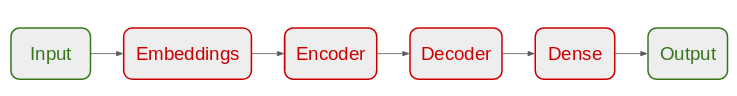

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sample data arrays (you should replace these with actual preprocessed sequence data)
# X: input sequence data (batch_size, input_seq_len)
# Y: target sequence data (batch_size, output_seq_len)
X = np.random.randint(1, 100, size=(1000, 10))
Y = np.random.randint(1, 100, size=(1000, 12))

# Vocabulary sizes
in_vocab = 100  # size of input vocabulary
out_vocab = 100  # size of output vocabulary

# Sequence lengths
in_timesteps = X.shape[1]
out_timesteps = Y.shape[1]

# Split into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Custom dataset class
class CustomSeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long).to(device)
        self.Y = torch.tensor(Y, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Dataset objects
train_dataset = CustomSeqDataset(X_train, y_train)
val_dataset = CustomSeqDataset(X_val, y_val)
test_dataset = CustomSeqDataset(X_test, y_test)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# NMT-like Model in PyTorch
class Seq2SeqModel(nn.Module):
    def __init__(self, in_vocab, out_vocab, in_timesteps, out_timesteps, units):
        super(Seq2SeqModel, self).__init__()
        self.embedding = nn.Embedding(in_vocab, units, padding_idx=0)
        self.encoder_lstm = nn.LSTM(units, units, batch_first=True)
        self.repeat_vector = nn.Linear(units, out_timesteps * units)
        self.decoder_lstm = nn.LSTM(units, units, batch_first=True)
        self.fc = nn.Linear(units, out_vocab)
        self.softmax = nn.LogSoftmax(dim=2)  # log softmax for NLLLoss

        self.units = units
        self.out_timesteps = out_timesteps

    def forward(self, x):
        x = self.embedding(x)  # (batch, in_timesteps, units)
        _, (h_n, _) = self.encoder_lstm(x)  # h_n: (1, batch, units)
        h_repeated = self.repeat_vector(h_n[-1])  # (batch, out_timesteps * units)
        h_repeated = h_repeated.view(-1, self.out_timesteps, self.units)  # (batch, out_timesteps, units)
        decoder_out, _ = self.decoder_lstm(h_repeated)  # (batch, out_timesteps, units)
        out = self.fc(decoder_out)  # (batch, out_timesteps, out_vocab)
        return self.softmax(out)

# Model initialization
units = 64
model = Seq2SeqModel(in_vocab, out_vocab, in_timesteps, out_timesteps, units).to(device)

# Print model summary
print(model)
